In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.max_columns', None)  # mostrar todas las columnas

Debido a que no se encntro informacion especifica del subsidio para la ciudad seleccionada, se tiene que estimar el subsidio y el consumo para todo el estado de Campeche

## Esto es para obtener el código para el estado

In [2]:
f = '../data/raw/catun_municipio/AGEEML_20258131423976_utf.csv'
ubica_geo = pd.read_csv(f, encoding="utf-8"
                       # usecols = ['folioviv','aire_acond','entidad','factor']
                      )
ubica_geo

,MAPA,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
0,1001,1,Aguascalientes,Ags.,1,Aguascalientes,0001,Aguascalientes,948990,462073,486917,266942
1,1002,1,Aguascalientes,Ags.,2,Asientos,0001,Asientos,51536,25261,26275,12544
2,1003,1,Aguascalientes,Ags.,3,Calvillo,0001,Calvillo,58250,28563,29687,15556
3,1004,1,Aguascalientes,Ags.,4,Cosío,0001,Cosío,17000,8292,8708,3938
4,1005,1,Aguascalientes,Ags.,5,Jesús María,0001,Jesús María,129929,64219,65710,33229
...,...,...,...,...,...,...,...,...,...,...,...,...
2473,32054,32,Zacatecas,Zac.,54,Villa Hidalgo,0001,Villa Hidalgo,19446,9504,9942,4951
2474,32055,32,Zacatecas,Zac.,55,Villanueva,0001,Villanueva,31558,15590,15968,9052
2475,32056,32,Zacatecas,Zac.,56,Zacatecas,0001,Zacatecas,149607,71972,77635,42424
2476,32057,32,Zacatecas,Zac.,57,Trancoso,0001,Trancoso,20455,10039,10416,4671


In [3]:
nombre_edo = "Campeche"
ubica_edo = ubica_geo[ubica_geo["NOM_ENT"].str.contains(nombre_edo, case=False, na=False)].copy()
ubica_edo

,MAPA,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
23,4001,4,Campeche,Camp.,1,Calkiní,0001,Calkiní,59232,29170,30062,15289
24,4002,4,Campeche,Camp.,2,Campeche,0001,San Francisco de Campeche,294077,141555,152522,85353
25,4003,4,Campeche,Camp.,3,Carmen,0001,Ciudad del Carmen,248845,123043,125802,72119
26,4004,4,Campeche,Camp.,4,Champotón,0001,Champotón,78170,39030,39140,21474
27,4005,4,Campeche,Camp.,5,Hecelchakán,0001,Hecelchakán,31917,15713,16204,8292
28,4006,4,Campeche,Camp.,6,Hopelchén,0001,Hopelchén,42140,21328,20812,10243
29,4007,4,Campeche,Camp.,7,Palizada,0001,Palizada,8683,4423,4260,2546
30,4008,4,Campeche,Camp.,8,Tenabo,0001,Tenabo,11452,5797,5655,3066
31,4009,4,Campeche,Camp.,9,Escárcega,0001,Escárcega,59923,29468,30455,16837
32,4010,4,Campeche,Camp.,10,Calakmul,0001,Xpujil,31714,16101,15613,8037


In [4]:
codigo = int(ubica_edo['CVE_ENT'].mean())
print(f'El codigo de {nombre_edo} es {codigo}')

El codigo de Campeche es 4


## Descripción de las variables (carácteristicas de la vivienda sin cargas electricas)
Para la limpieza de datos se utilizaron XXX variables.

### folioviv: Identificador de la vivienda
Identificador de la vivienda compuesto por dos dígitos con la clave de la entidad federativa, uno con el ámbito (urbano, código diferente a 6;
rural, código 6), cuatro dígitos del número consecutivo de la UPM, un dígito de la decena de levantamiento y dos dígitos con un número consecutivo para la vivienda seleccionada. Se ubica en todas las tablas.

Es la llave que nos permite correlacionar difertes tablas de la ENIGH y tal vez de la ENUT XXX. Con el digito que corresponde a rural o urbano, podremos ver cuales datos corresponden a la ciudad y cuales a los pueblos cercanos. 

### ubica_geo: Ubicación geográfica
Contiene la ubicación geográfica de la vivienda. Los dos primeros dígitos representan la clave de la entidad y los siguientes tres la clave del
municipio. Estas corresponden al Catálogo de claves de entidades federativas, municipios y localidades, que está disponible en el sitio del INEGI
https://www.inegi.org.mx/app/ageeml/

Nos permite separar los datos por municipio. Se ubica en la tabla "viviendas".


### factor: Factor de expansión 
El factor de expansión constituye el peso que se le da a cada unidad muestral para generalizar los resultados de la muestra a la población. Se ubica en todas las tablas.

### disp_elect: Disponibilidad eléctrica
Fuente de donde se obtiene la energía eléctrica en la vivienda. Será útil para seleccionar solo a quienes tienen servicio electrico (para poder asignarles un consumo en kWh a partir de lo que pagaron en MNX del 2024). Se ubica en la tabla "viviendas".

1. = Del servicio público
2. = De una planta particular
3. = De panel solar
4. = De otra fuente
5. = No tiene luz eléctrica

### tot_hog: Total de hogares en la vivienda
En una misma vivienda pueden haber varios hogares, por ejemplo, que en el primer piso viva una familia y en el segundo otra. En este estudio se consideraran a todos los hogares de una vivienda como uno solo. Se ubica en la tabla "viviendas".

### gasto_tri, Gasto trimestral
El gasto trimestral normalizado de acuerdo a la decena de levantamiento en la ENIGH significa que el INEGI ajusta los gastos reportados por los hogares para hacerlos comparables, ya que las entrevistas se realizan en diferentes “decenas de levantamiento” (bloques de 10 días). Como cada hogar declara sus gastos en periodos de referencia distintos según cuándo fue encuestado, la normalización corrige esas diferencias temporales, por ejemplo, variaciones de precios o de temporada y así el gasto trimestral refleja un periodo estándar común para toda la muestra.

Para fines de este trabajo solo se consideran los gastos relacionados con el consumo de electricidad, para ello se filtran los que contengan la clave 045100 y se suman los valores de todos los hogares que habiten en la misma vivienda. 

## Descripción de las variables (carácteristicas de los residentes)

Las variables de esta seccion se encuentran en dos tablas, vivinedas y POBLACION. Todas nos pueden ser útiles para coorelacionar con los datos de la encuesta ENUT.

### tot_resid: Total de residentes de la vivienda
Número de personas que habitan la vivienda, muy útil para los perfiles de ocupación y consumo. Se ubica en la tabla "viviendas".

## Como coorrelacionar las encuestas ENIGH y ENUT

No se pueden correlacionar directamente a nivel de individuo o de hogar, porque cada encuesta tiene su propio marco muestral y su propio levantamiento. Es decir, las encuestas no entrevistan a las mismas personas ni usan un identificador común que permita “unir” observaciones una a una. Por estas razones, es necesario encontrar caracteristicas que compartan ambas encuestas para poder separar grupos y determinar indices de cada uno, por ejemplo, por el estado y estrato economico, etc. 


## Importar y acotar tabla VIVIENDA

In [5]:
f = '../data/raw/enigh2024_ns_viviendas_csv/viviendas.csv'
VIVIENDA = pd.read_csv(f, 
                       usecols = ['folioviv','ubica_geo','factor'
                                  # ,'tipo_viv', 'mat_pared','mat_techos','mat_pisos',
                                  # 'cuart_dorm','num_cuarto',
                                  # # no se incluyeron banos
                                  ,'disp_elect'
                                  # ,'tot_resid'
                                  # ,'est_socio',
                                  # # 'tot_hog',
                                  # # Abajo son cargas electricas
                                  # 'aire_acond','calefacc',
                                  # 'focos','focos_ahor', 
                                  # 'combus'
                                 ] #Es el combustible para cocinar, si es electricidad (5) va a representar una carga electrica importante
                      )
VIVIENDA

,folioviv,disp_elect,ubica_geo,factor
0,100001901,1,1001,207
1,100001902,1,1001,207
2,100001904,1,1001,207
3,100001905,1,1001,207
4,100002501,1,1001,196
...,...,...,...,...
90319,3260593814,1,32052,183
90320,3260593815,1,32052,183
90321,3260593816,1,32052,183
90322,3260593817,1,32052,183


In [6]:
VIVIENDA.dtypes

folioviv      int64
disp_elect    int64
ubica_geo     int64
factor        int64
dtype: object

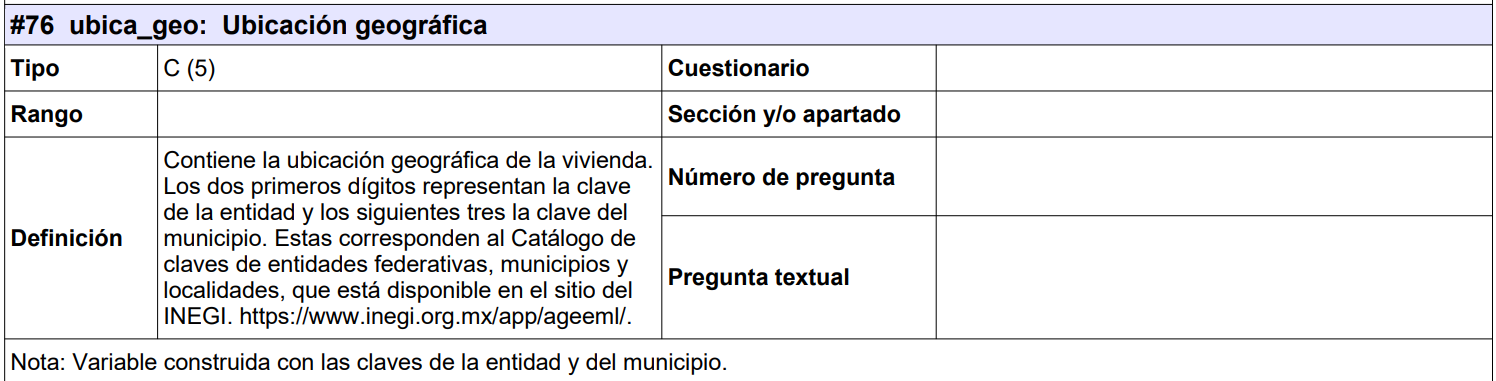

In [7]:
VIVIENDA_edo = VIVIENDA[VIVIENDA['ubica_geo'].astype(str).str.startswith(f'{codigo}')].copy()
VIVIENDA_edo

,folioviv,disp_elect,ubica_geo,factor
9635,401161019,1,4001,141
9636,401161020,1,4001,141
9637,401161021,1,4001,141
9638,401161022,1,4001,141
9639,401161024,1,4001,141
...,...,...,...,...
11824,461430920,3,4011,124
11825,461430921,1,4011,124
11826,461430922,1,4011,124
11827,461430923,1,4011,124


In [8]:
viv_original_edo = VIVIENDA_edo['factor'].sum()
viv_original_edo

np.int64(270527)

# Importar tabla GASTOHOGAR, filtrar gastos de electricidad por vivienda para el estado

In [9]:
f = '../data/raw/enigh2024_ns_gastoshogar_csv/gastoshogar.csv'
GASTOHOGAR = pd.read_csv(f, 
                       usecols = ['folioviv',
                                  'foliohog',
                                  'clave',
                                  'gasto_tri',
                                  'num_meses','gasto',
                                  'ultim_pago',
                                  'entidad',
                                  'factor'
                                 ]
                      )
GASTOHOGAR

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor
0,100001901,1,011131,13,,,167.14,1,207
1,100001901,1,011150,50,,,642.85,1,207
2,100001901,1,011231,15,,,192.85,1,207
3,100001901,1,011411,38,,,488.57,1,207
4,100001901,1,011460,114,,,1465.71,1,207
...,...,...,...,...,...,...,...,...,...
5311492,3260593818,1,131208,100,,,300,32,183
5311493,3260593818,1,13120A,70,,,210,32,183
5311494,3260593818,1,13120L,120,,,360,32,183
5311495,3260593818,1,181126,15,,,192.85,32,183


In [10]:
# Esto es para quedarnos solo con los gastos relacionados con la energia electrica 

GASTOHOGAR_luz = GASTOHOGAR[GASTOHOGAR['clave'] == '045100'].copy()

# Necesitamos que esras columnas sean numericas 
GASTOHOGAR_luz['gasto_tri'] = pd.to_numeric(GASTOHOGAR_luz['gasto_tri'], errors='coerce')
GASTOHOGAR_luz['num_meses'] = pd.to_numeric(GASTOHOGAR_luz['num_meses'], errors='coerce')
GASTOHOGAR_luz['gasto'] = pd.to_numeric(GASTOHOGAR_luz['gasto'], errors='coerce')
GASTOHOGAR_luz

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor
13,100001901,1,045100,130.0,2.0,2410,195.0,1,207
53,100001902,1,045100,600.0,2.0,2410,900.0,1,207
99,100001904,1,045100,442.0,2.0,2410,663.0,1,207
167,100001905,1,045100,183.0,2.0,2410,274.5,1,207
274,100002501,1,045100,321.0,2.0,2408,481.5,1,196
...,...,...,...,...,...,...,...,...,...
5311270,3260593814,1,045100,120.0,2.0,2408,180.0,32,183
5311341,3260593815,1,045100,300.0,2.0,2408,450.0,32,183
5311397,3260593816,1,045100,280.0,2.0,2408,420.0,32,183
5311436,3260593817,1,045100,120.0,2.0,2408,180.0,32,183


In [11]:
GASTOHOGAR_luz_original = GASTOHOGAR_luz.copy()

In [12]:
GASTOHOGAR_luz_original['factor'].sum()*(100 - 3.18 - 94.22)/100

np.float64(919050.2099999981)

In [13]:
periodos = (
    GASTOHOGAR_luz_original
    .groupby('num_meses')['factor']
    .sum()
    .reset_index()
)
# periodos.columns = ['num_meses', 'weighted_count']

periodos.columns = ['meses', 'conteo']
periodos['meses'] = periodos['meses'].astype(int)
periodos['%'] = periodos['conteo']/GASTOHOGAR_luz_original['factor'].sum()*100
periodos['%'] = periodos['%'].round(2)
periodos

,meses,conteo,%
0,1,1123932,3.18
1,2,33304210,94.22
2,3,30749,0.09
3,4,34701,0.10
4,5,24950,0.07
5,6,144187,0.41
6,7,5919,0.02
7,8,8615,0.02
8,9,13887,0.04
9,10,5209,0.01


<Axes: >

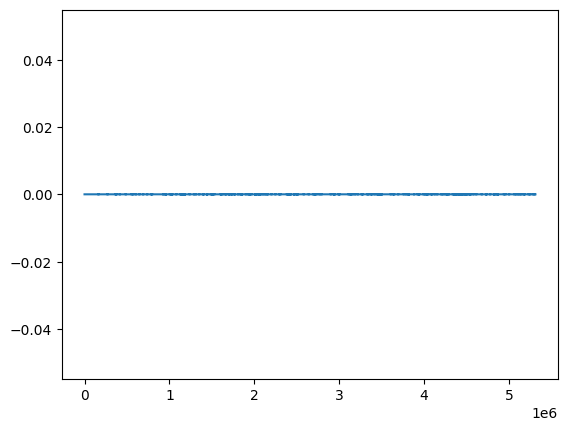

In [14]:
# La CFE solo reconoce formalemnte 2 periodos de facturacion para contratos domesticos, el mensual y el bimestral https://app.cfe.mx/Aplicaciones/CCFE/Tarifas/TarifasCRECasa/Tarifas/DEPDomesticas.aspx?utm_source=chatgpt.com
# ademas, en la ENIGH se pregunta a cuantos meses corresponde el pago, el hecho de que sean mas de 2, sugiere que se trata de pagos con deudas 
# por atraso de pago, reconexion, etc, por ello es importante desecharlos
mes = [1,2]
GASTOHOGAR_luz = GASTOHOGAR_luz.loc[GASTOHOGAR_luz['num_meses'].isin(mes)].copy()
GASTOHOGAR_luz['prueba'] = GASTOHOGAR_luz['gasto'] / GASTOHOGAR_luz['num_meses'] * 3 - GASTOHOGAR_luz['gasto_tri'] 
GASTOHOGAR_luz['prueba'].plot()

In [15]:
viv_tiradas_periodo_fact = GASTOHOGAR_luz_original['factor'].sum() - GASTOHOGAR_luz['factor'].sum()
porcent_tiradas_periodo_fact = viv_tiradas_periodo_fact/ GASTOHOGAR_luz_original['factor'].sum() *100
## corregir XXX
print(f''' Por tener un periodo de facturacion diferente a 1 o 2, para todo Mexico se tiraron {viv_tiradas_periodo_fact:,} datos de hogares 
que tenian datos de consumo de electricidad, corresponden al {round(porcent_tiradas_periodo_fact,2)}%''')

 Por tener un periodo de facturacion diferente a 1 o 2, para todo Mexico se tiraron 919,943 datos de hogares 
que tenian datos de consumo de electricidad, corresponden al 2.6%


In [16]:
tirados_NaN_gasto = GASTOHOGAR_luz_original.loc[GASTOHOGAR_luz_original.isna().any(axis=1), 'factor'].sum()
porcent_tirados_NaN_gasto = GASTOHOGAR_luz_original.loc[GASTOHOGAR_luz_original.isna().any(axis=1), 'factor'].sum()/GASTOHOGAR_luz_original['factor'].sum() *100
print(f''' Por tener valores incompletos, para todo Mexico se tiraron {tirados_NaN_gasto:,} datos de hogares 
que tenian datos de consumo de electricidad, corresponden al {round(porcent_tirados_NaN_gasto,2)}%''')

 Por tener valores incompletos, para todo Mexico se tiraron 668,262 datos de hogares 
que tenian datos de consumo de electricidad, corresponden al 1.89%


In [17]:
GASTOHOGAR_luz = GASTOHOGAR_luz.drop(columns=['gasto_tri'])

def combinar_hogares(g):
    # Tomar primera fila del grupo
    fila = g.iloc[0].copy()
    # Reemplazar gasto con la suma del grupo
    fila['gasto'] = g['gasto'].sum()
    return fila

GASTOVIV_luz = GASTOHOGAR_luz.groupby('folioviv', as_index=False).apply(combinar_hogares)
GASTOVIV_luz

C:\Users\roele\AppData\Local\Temp\ipykernel_27112\3528329913.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  GASTOVIV_luz = GASTOHOGAR_luz.groupby('folioviv', as_index=False).apply(combinar_hogares)


,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,entidad,factor,prueba
0,100001901,1,045100,130.0,2.0,2410,1,207,0.0
1,100001902,1,045100,600.0,2.0,2410,1,207,0.0
2,100001904,1,045100,442.0,2.0,2410,1,207,0.0
3,100001905,1,045100,183.0,2.0,2410,1,207,0.0
4,100002501,1,045100,321.0,2.0,2408,1,196,0.0
...,...,...,...,...,...,...,...,...,...
79890,3260593814,1,045100,120.0,2.0,2408,32,183,0.0
79891,3260593815,1,045100,300.0,2.0,2408,32,183,0.0
79892,3260593816,1,045100,280.0,2.0,2408,32,183,0.0
79893,3260593817,1,045100,120.0,2.0,2408,32,183,0.0


In [18]:
VIVIENDA['factor'].sum() - GASTOHOGAR_luz_original['factor'].sum()

np.int64(3007957)

In [19]:
#Filtramos para quedarnos con los datos del estado de Campeche
GASTOVIV_luz_edo = GASTOVIV_luz[GASTOVIV_luz['entidad'] == 4].copy()

In [20]:
repetidos = GASTOVIV_luz_edo[
    GASTOVIV_luz_edo['folioviv'].duplicated(keep=False)
]
repetidos

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,entidad,factor,prueba


In [21]:
GASTOVIV_luz_edo = GASTOVIV_luz_edo[['folioviv','gasto','num_meses','ultim_pago']]
GASTOVIV_luz_edo = GASTOVIV_luz_edo.reset_index()
GASTOVIV_luz_edo = GASTOVIV_luz_edo.rename(columns={
    'gasto': 'gasto_mes'
})

# Obtener edo_df con los datos de VIVIENDA_edo y GASTOHOGAR_luz_edo

In [22]:
VIVIENDA_edo = VIVIENDA_edo.reset_index()
VIVIENDA_edo['factor'].sum()
# VIVIENDA_edo

np.int64(270527)

In [23]:
repetidos = VIVIENDA_edo[
    VIVIENDA_edo['folioviv'].duplicated(keep=False)
]
repetidos

,index,folioviv,disp_elect,ubica_geo,factor


In [24]:
# Merge completo con VIVIENDA_HOGAR_edo y GASTOHOGAR_luz_edo
edo_df = (
    pd.merge(
        VIVIENDA_edo,
        GASTOVIV_luz_edo,
        on='folioviv',
        how='outer',
        indicator=False
    )
    .reset_index(drop=True)
)
edo_df = edo_df.loc[:, ~edo_df.columns.str.contains('^level_0$|^index_')]


In [25]:
repetidos = edo_df[
    edo_df['folioviv'].duplicated(keep=False)
]
repetidos

,folioviv,disp_elect,ubica_geo,factor,gasto_mes,num_meses,ultim_pago


In [26]:
tirados_NaN_gasto_periodo = edo_df.loc[edo_df.isna().any(axis=1), 'factor'].sum()
porcent_tirados_NaN_gasto_periodo = tirados_NaN_gasto_periodo/edo_df['factor'].sum()*100

print(f''' Por tener valores incompletos, y un periodo diferente a 1 o 2 meses, para Campeche se tiraron {tirados_NaN_gasto_periodo:,} datos de hogares 
que corresponden al {round(porcent_tirados_NaN_gasto_periodo,2)}%''')

 Por tener valores incompletos, y un periodo diferente a 1 o 2 meses, para Campeche se tiraron 26,243 datos de hogares 
que corresponden al 9.7%


In [27]:
# Se tiran datos por no tener conexion con la CFE 
edo_df = edo_df[edo_df['disp_elect'] == 1]
viv_tiradas_no_CFE = viv_original_edo - edo_df['factor'].sum()
porcent_viv_tiradas_no_CFE = viv_tiradas_no_CFE/viv_original_edo

print(f''' Por tener por no tener conexion con la CFE , para Campeche se tiraron {viv_tiradas_no_CFE:,} datos de hogares 
que corresponden al {round(porcent_viv_tiradas_no_CFE,2)}%''')

 Por tener por no tener conexion con la CFE , para Campeche se tiraron 3,265 datos de hogares 
que corresponden al 0.01%


In [28]:
edo_df['factor'].sum()

np.int64(267262)

In [29]:
edo_df.isna().sum()

folioviv        0
disp_elect      0
ubica_geo       0
factor          0
gasto_mes     197
num_meses     197
ultim_pago    197
dtype: int64

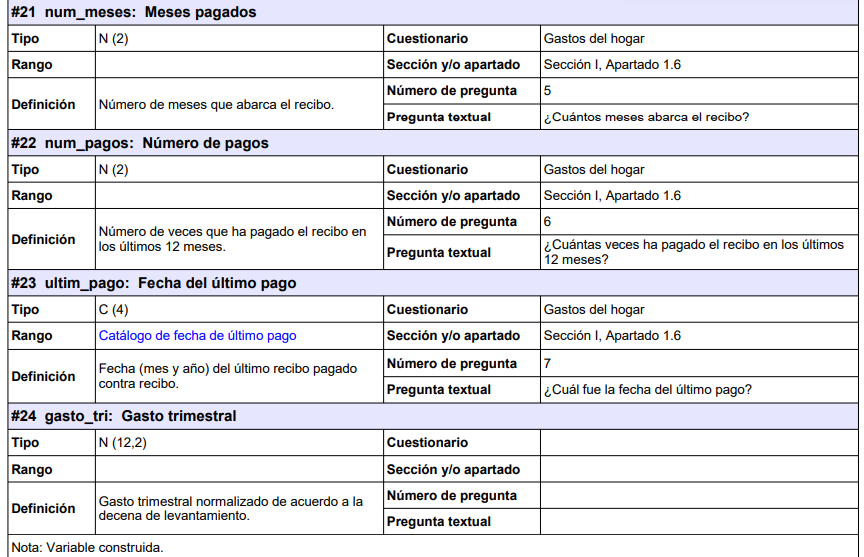

In [30]:
# Esto esta mal, lo que se representa en la fecha del último pago es el mes y el año
# Pero creo que es año y mes (primero el año)
edo_df["mes_cobro"] = (
    edo_df["ultim_pago"]
    .astype(str)
    .str[-2:]          # últimos dos dígitos
    # .map(mapa_meses)   # asignar nombre del mes
)
edo_df["dia_cobro"] = (
    edo_df["ultim_pago"]
    .astype(str)
    .str[0:2]
    # .int()# primeros dos dígitos
)
edo_df['dia_cobro'] = pd.to_numeric(edo_df['dia_cobro'], errors='coerce')
edo_df['mes_cobro'] = pd.to_numeric(edo_df['mes_cobro'], errors='coerce')

edo_df

,folioviv,disp_elect,ubica_geo,factor,gasto_mes,num_meses,ultim_pago,mes_cobro,dia_cobro
0,401161019,1,4001,141,NaN,NaN,NaN,NaN,NaN
1,401161020,1,4001,141,250.0,2.0,2409,9.0,24.0
2,401161021,1,4001,141,388.0,2.0,2409,9.0,24.0
3,401161022,1,4001,141,485.0,2.0,2409,9.0,24.0
4,401161024,1,4001,141,300.0,2.0,2409,9.0,24.0
...,...,...,...,...,...,...,...,...,...
2187,461430718,1,4011,124,NaN,NaN,NaN,NaN,NaN
2190,461430921,1,4011,124,NaN,NaN,NaN,NaN,NaN
2191,461430922,1,4011,124,20.0,1.0,2410,10.0,24.0
2192,461430923,1,4011,124,25.0,1.0,2410,10.0,24.0


In [31]:
edo_df['factor'].sum()

np.int64(267262)

In [32]:
VIVIENDA_edo['factor'].sum()

np.int64(270527)

In [33]:
# Se considera la fecha de pago como si todos los usuarios hubieran pagado el ultimo dia, por lo tanto, el recibo tuvo que haberse emitido 
# 10 dias antes, "El suministrador deberá conceder al usuario un plazo de diez días naturales a partir de la fecha de entrega del aviso-recibo 
# por parte del mismo suministrador, para cubrir el monto del adeudo https://www.cfe.gob.mx/finanzas/financiamiento/Documents/Emisiones%20Nacionales/CFE--Programa%20%20CBs%202016--Prospecto%20Colocaci%C3%B3n%20Definitivo.pdf?csf=1&e=4Vcf0I&utm_source=chatgpt.com

# Asimismo, en el caso de los servicios con Facturación bimestral, el "USUARIO DE SUMINISTRO BÁSICO" acepta que las Cuotas 
# aplicables para todo el consumo serán las vigentes treinta días naturales antes de la fecha de término del periodo que abarca
# dicha Facturación. https://dof.gob.mx/nota_detalle_popup.php?codigo=5628991

# Estas dos implicaciones se consideran de la siguiente manera, si el dia de pago es durante los primeros 10 dias del mes, quiere decir que el recibo
# se emitio al final del mes anterior, y como indica la segunda cita, el precio que toman en cuenta es 30 dias antes de que termine el periodo de facturacion
# por ello se le resta un mes mas, 2 en total 
# Para los casos en los que el recibo se emitio el mismo dia del pago, solo se resta un mes (por los 30 dias que se tienen que retroceder segun la 
# segunda cita) 

def calcular_mes_tarifa(df):
    def regla(dia, mes):
        # Si falta algún dato → NaN
        if pd.isna(dia) or pd.isna(mes):
            return np.nan
        
        # Aplicar reglas
        if dia <= 10:
            mes_tarifa = mes - 2
            if mes_tarifa <= 2:
                mes_tarifa = 12 - mes_tarifa
            return mes_tarifa
        elif 10 < dia <= 31:
            mes_tarifa = mes - 1
            if mes_tarifa == 0:
                mes_tarifa = 12
            return mes_tarifa
        else:
            return np.nan  # Día inválido

    df['mes_tarifa'] = df.apply(lambda row: regla(row['dia_cobro'], row['mes_cobro']), axis=1)
    return df

In [34]:
edo_df = calcular_mes_tarifa(edo_df)
edo_df

,folioviv,disp_elect,ubica_geo,factor,gasto_mes,num_meses,ultim_pago,mes_cobro,dia_cobro,mes_tarifa
0,401161019,1,4001,141,NaN,NaN,NaN,NaN,NaN,NaN
1,401161020,1,4001,141,250.0,2.0,2409,9.0,24.0,8.0
2,401161021,1,4001,141,388.0,2.0,2409,9.0,24.0,8.0
3,401161022,1,4001,141,485.0,2.0,2409,9.0,24.0,8.0
4,401161024,1,4001,141,300.0,2.0,2409,9.0,24.0,8.0
...,...,...,...,...,...,...,...,...,...,...
2187,461430718,1,4011,124,NaN,NaN,NaN,NaN,NaN,NaN
2190,461430921,1,4011,124,NaN,NaN,NaN,NaN,NaN,NaN
2191,461430922,1,4011,124,20.0,1.0,2410,10.0,24.0,9.0
2192,461430923,1,4011,124,25.0,1.0,2410,10.0,24.0,9.0


In [35]:
mapa_meses = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre"
}

edo_df['mes_tarifa_nombre'] = (
    edo_df['mes_tarifa']
    .map(mapa_meses)
)

edo_df

,folioviv,disp_elect,ubica_geo,factor,gasto_mes,num_meses,ultim_pago,mes_cobro,dia_cobro,mes_tarifa,mes_tarifa_nombre
0,401161019,1,4001,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,401161020,1,4001,141,250.0,2.0,2409,9.0,24.0,8.0,agosto
2,401161021,1,4001,141,388.0,2.0,2409,9.0,24.0,8.0,agosto
3,401161022,1,4001,141,485.0,2.0,2409,9.0,24.0,8.0,agosto
4,401161024,1,4001,141,300.0,2.0,2409,9.0,24.0,8.0,agosto
...,...,...,...,...,...,...,...,...,...,...,...
2187,461430718,1,4011,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2190,461430921,1,4011,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2191,461430922,1,4011,124,20.0,1.0,2410,10.0,24.0,9.0,septiembre
2192,461430923,1,4011,124,25.0,1.0,2410,10.0,24.0,9.0,septiembre


In [36]:
meses = ["enero","febrero","marzo", "abril","mayo","junio","julio","agosto","septiembre","octubre", "noviembre", "diciembre"]
## XXX hay que revisar a que nos referimos con eso 
viv_calculables = edo_df.loc[edo_df['mes_tarifa_nombre'].notna(), 'factor'].sum()

viv_meses = {}

for mes in meses:
    viv_meses[mes] = edo_df.loc[edo_df['mes_tarifa_nombre'] == mes, 'factor'].sum()
    
tabla = pd.DataFrame({
    "mes": meses,
    "Viviendas": [viv_meses[mes] for mes in meses],
})

tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# Formato con separador de miles
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")
tabla

,mes,Viviendas,Porcentaje (%)
0,enero,256,0.11
1,febrero,0,0.00
2,marzo,745,0.31
3,abril,755,0.31
4,mayo,"7,067",2.91
5,junio,"40,518",16.69
6,julio,"59,132",24.35
7,agosto,"79,303",32.66
8,septiembre,"51,320",21.13
9,octubre,"3,326",1.37


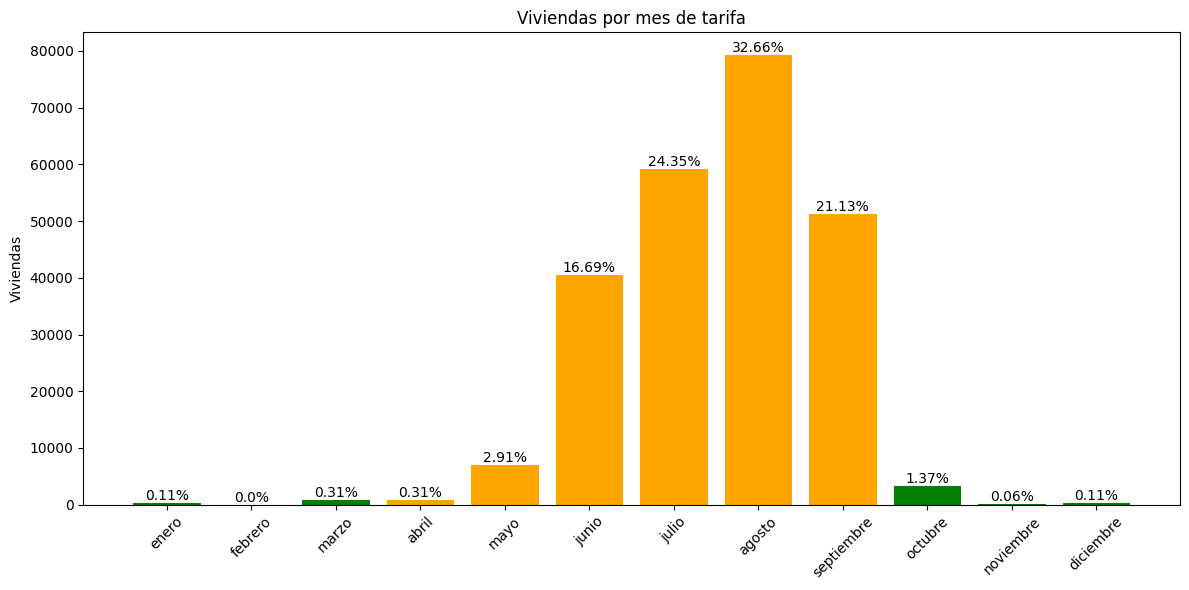

In [37]:
# Copia para graficar y asegurar que Viviendas sea numérica
tabla_plot = tabla.copy()
tabla_plot["Viviendas"] = tabla_plot["Viviendas"].replace({",": ""}, regex=True).astype(int)

# Meses que deben ir en color naranja
meses_naranja = ["abril", "mayo", "junio", "julio", "agosto", "septiembre"]

# Asignar color a cada barra
colores = ["orange" if mes in meses_naranja else "green" for mes in tabla_plot["mes"]]

# Crear la gráfica
plt.figure(figsize=(12,6))
bars = plt.bar(tabla_plot["mes"], tabla_plot["Viviendas"], color=colores)

plt.xticks(rotation=45)
plt.ylabel("Viviendas")
plt.title("Viviendas por mes de tarifa")

# Agregar los porcentajes arriba de cada barra
for bar, pct in zip(bars, tabla_plot["Porcentaje (%)"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height,
        f"{pct}%", 
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()


In [38]:
verano = ["abril","mayo","junio","julio","agosto","septiembre"]
no_verano = ["enero","febrero","marzo", "octubre", "noviembre", "diciembre"]
    

viv_verano = edo_df.loc[edo_df['mes_tarifa_nombre'].isin(verano), 'factor'].sum()
viv_no_verano = edo_df.loc[edo_df['mes_tarifa_nombre'].isin(no_verano), 'factor'].sum()

viv_calculables = edo_df.loc[edo_df['mes_tarifa_nombre'].notna(), 'factor'].sum()

tabla = pd.DataFrame({
    "Temporada": ["Verano", "Fuera de verano"],
    "Viviendas": [viv_verano, viv_no_verano],
})

tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# Formato con separador de miles
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")
tabla

,Temporada,Viviendas,Porcentaje (%)
0,Verano,"238,095",98.05
1,Fuera de verano,"4,739",1.95


In [39]:
(viv_verano+viv_no_verano)/viv_original_edo*100

np.float64(89.7633138281946)

In [40]:
# print(f'Total gastado en Campeche para la energia electrica {(edo_df['gasto_mes'] * edo_df['factor']).sum():,}')

## El IVA corresponde al 16% y el DAP corresponde al 6%, en total de impuestos son 22%

## Cuantos no recibieron subsidio? tarifa DAC

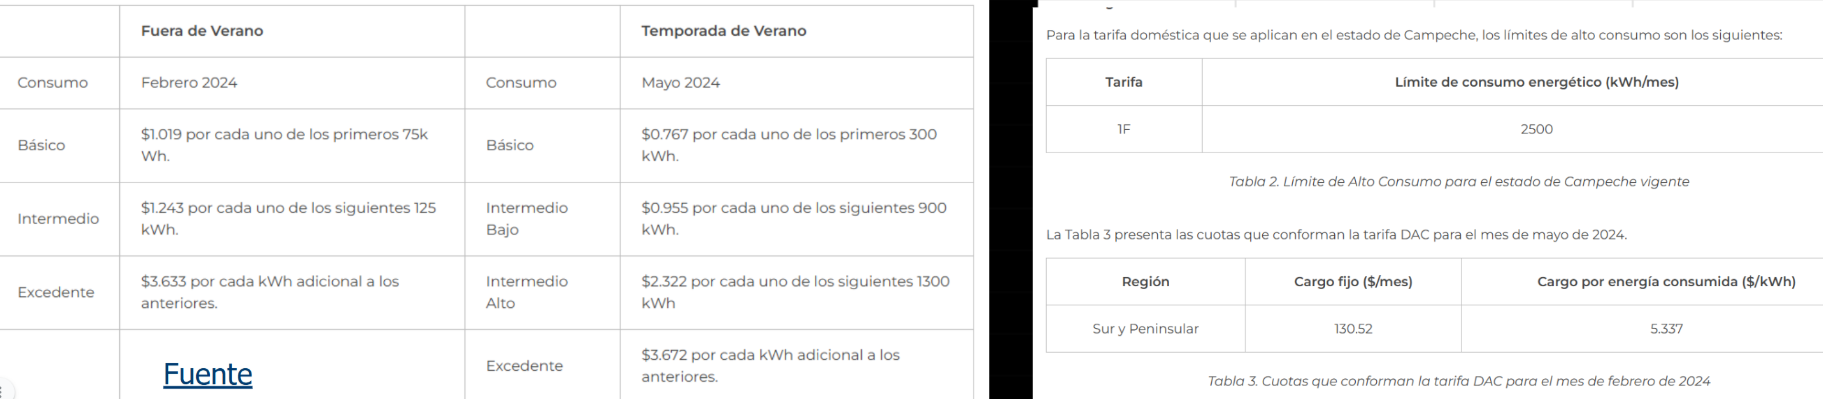

In [41]:
parametros = {
    "enero": {
        "min_men": 1.015 * 25 * 1.22,
        "basico": 1.015 * 75 * 1.22,
        "intermedio": 1.239 * 125 * 1.22
    },
    "febrero": {
        "min_men": 1.019 * 25 * 1.22,
        "basico": 1.019 * 75 * 1.22,
        "intermedio": 1.243 * 125 * 1.22
    },
    "marzo": {
        "min_men": 1.023 * 25 * 1.22,
        "basico": 1.023 * 75 * 1.22,
        "intermedio": 1.247 * 125 * 1.22
    },
    "abril": {
        "min_men": 0.764 * 25 * 1.22,
        "basico": 0.764 * 300 * 1.22,
        "intermedio_bajo": 0.952 * 900 * 1.22,
        "intermedio_alto": 2.314 * 1300 * 1.22
    },
    "mayo": {
        "min_men": 0.767 * 25 * 1.22,
        "basico": 0.767 * 300 * 1.22,
        "intermedio_bajo": 0.955 * 900 * 1.22,
        "intermedio_alto": 2.322 * 1300 * 1.22
    },
    "junio": {
        "min_men": 0.770 * 25 * 1.22,
        "basico": 0.770 * 300 * 1.22,
        "intermedio_bajo": 0.958 * 900 * 1.22,
        "intermedio_alto": 2.330 * 1300 * 1.22
    },
    "julio": {
        "min_men": 0.773 * 25 * 1.22,
        "basico": 0.773 * 300 * 1.22,
        "intermedio_bajo": 0.961 * 900 * 1.22,
        "intermedio_alto": 2.338 * 1300 * 1.22
    },
    "agosto": {
        "min_men": 0.776 * 25 * 1.22,
        "basico": 0.776 * 300 * 1.22,
        "intermedio_bajo": 0.964 * 900 * 1.22,
        "intermedio_alto": 2.346 * 1300 * 1.22
    },
    "septiembre": {
        "min_men": 0.779 * 25 * 1.22,
        "basico": 0.779 * 300 * 1.22,
        "intermedio_bajo": 0.967 * 900 * 1.22,
        "intermedio_alto": 2.354 * 1300 * 1.22
    },
    "octubre": {
        "min_men": 1.051 * 25 * 1.22,
        "basico": 1.275 * 75 * 1.22,
        "intermedio": 3.737 * 125 * 1.22,
    },
    "noviembre": {
        "min_men": 1.055 * 25 * 1.22,
        "basico": 1.280 * 75 * 1.22,
        "intermedio": 3.750 * 125 * 1.22,
    },
    "diciembre": {
        "min_men": 1.059 * 25 * 1.22,
        "basico": 1.059 * 75 * 1.22,
        "intermedio": 1.285 * 125 * 1.22
    },
}
verano = ["abril","mayo","junio","julio","agosto","septiembre"]
no_verano = ["enero","febrero","marzo", "octubre", "noviembre", "diciembre"]

def get_bloque(row):

    mes = row["mes_tarifa_nombre"]

    # Si no existe en el diccionario o es NaN, devolver NaN
    if mes not in parametros:
        return np.nan
    elif mes in verano: 
        # Obtener parámetros del mes
        min_men = parametros[mes]["min_men"]
        basico = parametros[mes]["basico"]
        intermedio_bajo = parametros[mes]["intermedio_bajo"]
        intermedio_alto = parametros[mes]["intermedio_alto"]

        gasto = row["gasto_mes"]

        if gasto <= min_men:
            return np.nan
        elif gasto <= basico:
            return "basico"
        elif gasto <= basico + intermedio_bajo:
            return "intermedio_bajo"
        elif gasto <= basico + intermedio_bajo + intermedio_alto:
            return "intermedio_alto"
        else:
            return "DAC"

    elif mes in no_verano: 
        # Obtener parámetros del mes
        min_men = parametros[mes]["min_men"]
        basico = parametros[mes]["basico"]
        intermedio = parametros[mes]["intermedio"]

        gasto = row["gasto_mes"]

        # Clasificación según umbrales del mes correspondiente
        if gasto <= min_men:
            return np.nan
        elif gasto <= basico:
            return "basico"
        elif gasto <= basico + intermedio:
            return "intermedio"
        else:
            return "DAC"

In [42]:
edo_df = edo_df.copy()
edo_df["bloque"] = edo_df.apply(get_bloque, axis=1)
edo_df

,folioviv,disp_elect,ubica_geo,factor,gasto_mes,num_meses,ultim_pago,mes_cobro,dia_cobro,mes_tarifa,mes_tarifa_nombre,bloque
0,401161019,1,4001,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,401161020,1,4001,141,250.0,2.0,2409,9.0,24.0,8.0,agosto,basico
2,401161021,1,4001,141,388.0,2.0,2409,9.0,24.0,8.0,agosto,intermedio_bajo
3,401161022,1,4001,141,485.0,2.0,2409,9.0,24.0,8.0,agosto,intermedio_bajo
4,401161024,1,4001,141,300.0,2.0,2409,9.0,24.0,8.0,agosto,intermedio_bajo
...,...,...,...,...,...,...,...,...,...,...,...,...
2187,461430718,1,4011,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2190,461430921,1,4011,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2191,461430922,1,4011,124,20.0,1.0,2410,10.0,24.0,9.0,septiembre,NaN
2192,461430923,1,4011,124,25.0,1.0,2410,10.0,24.0,9.0,septiembre,basico


In [43]:
intermedios = ["intermedio_bajo", "intermedio", 'intermedio_alto']

bases = edo_df.loc[edo_df['bloque'] == 'basico', 'factor'].sum()
intermedios = edo_df.loc[edo_df['bloque'].isin(intermedios), 'factor'].sum()
DACs = edo_df.loc[edo_df['bloque'] == 'DAC', 'factor'].sum()
viv_calculables = edo_df.loc[edo_df['bloque'].notna(), 'factor'].sum()
bloque_nan = edo_df.loc[edo_df['bloque'].isna(), 'factor'].sum()

# print(f''' Hay {bases:,} ({round(bases/viv_calculables*100,2):,}%) vivinedas en bloque basico, 
# {intermedios:,} ({round(intermedios/viv_calculables*100,2):,}%)en intermedio y {DACs:,} ({round(DACs/viv_calculables*100,2):,}%) en DAC
#  y {bloque_nan:,} ({round(bloque_nan/viv_calculables*100,2):,}%) sin bloque''')
tabla = pd.DataFrame({
    "Bloque": ["basico", "intermedios", "DAC", "sin_bloque"],
    "Viviendas": [bases, intermedios, DACs, bloque_nan],
})

tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# Formato con separador de miles
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")
tabla

,Bloque,Viviendas,Porcentaje (%)
0,basico,"69,970",28.90
1,intermedios,"167,937",69.36
2,DAC,"4,221",1.74
3,sin_bloque,"25,134",10.38


In [44]:
edo_df['bloque'].value_counts(dropna=False)

bloque
intermedio_bajo    1023
basico              558
intermedio_alto     339
NaN                 202
DAC                  35
intermedio           11
Name: count, dtype: int64

Como el subsidio solo corresponde a las viviendas sin tarifa DAC y en verano, hay que ver cuantas son: 

In [45]:
# tabla_plot = tabla.copy()
# tabla_plot["Viviendas_num"] = tabla_plot["Viviendas"].str.replace(",", "").astype(int)

# # Extraer categorías sin los totales
# filtros = ["Tarifa 1F", "DAC", "Sin bloque"]

# categorias = []
# valores_verano = []
# valores_no_verano = []
# porc_verano = []
# porc_no_verano = []

# for base in filtros:
#     # Buscar filas en la tabla
#     verano_row = tabla_plot[tabla_plot["Categoria"] == f"{base} (Verano)"].iloc[0]
#     no_verano_row = tabla_plot[tabla_plot["Categoria"] == f"{base} (No Verano)"].iloc[0]

#     categorias.append(base)
#     valores_verano.append(verano_row["Viviendas_num"])
#     valores_no_verano.append(no_verano_row["Viviendas_num"])
#     porc_verano.append(verano_row["Porcentaje (%)"])
#     porc_no_verano.append(no_verano_row["Porcentaje (%)"])

# # --- Preparar gráfico ---
# x = np.arange(len(categorias))
# width = 0.35

# plt.figure(figsize=(10,6))

# # Barras
# b1 = plt.bar(x - width/2, valores_no_verano, width, label="No Verano", color="steelblue")
# b2 = plt.bar(x + width/2, valores_verano, width, label="Verano", color="indianred")

# # Etiquetas de porcentaje arriba de cada barra
# for i, rect in enumerate(b1):
#     plt.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
#              f"{porc_no_verano[i]}%", ha="center", va="bottom", fontsize=10)

# for i, rect in enumerate(b2):
#     plt.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
#              f"{porc_verano[i]}%", ha="center", va="bottom", fontsize=10)

# # --- Opciones de presentación ---
# plt.xticks(x, categorias, fontsize=12)
# plt.ylabel("Número de viviendas", fontsize=12)
# plt.title("Comparación de viviendas por temporada y categoría", fontsize=14)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [46]:
# calculables_sin_verano_1F = tabla_plot.loc[tabla_plot['Categoria'] == 'Tarifa 1F (No Verano)', 'Viviendas_num'].sum() + tabla_plot.loc[tabla_plot['Categoria'] == 'DAC (Total)', 'Viviendas_num'].sum()
# viv_calculables = edo_df.loc[edo_df['bloque'].notna(), 'factor'].sum()
# viv_total = viv_original_edo

# print(f'''Si no consideramos las viviendas en 1F en verano, podemos calcular el consumo de: 
# {calculables_sin_verano_1F:,} que es el {round(calculables_sin_verano_1F/viv_calculables*100,2)} % de las que se podian calcular y {round(calculables_sin_verano_1F/viv_total*100,2)}% del original''')

In [47]:
viv_fin = edo_df.loc[edo_df['bloque'].notna(), 'factor'].sum()
porcent_viv_fin = viv_fin/viv_original_edo*100
print(viv_fin, porcent_viv_fin)

242128 89.50234172559486


In [48]:
verano = ["abril","mayo","junio","julio","agosto","septiembre"]

df_verano = edo_df.loc[edo_df['mes_tarifa_nombre'].isin(verano)]

viv_verano = df_verano.loc[edo_df['bloque'].notna(), 'factor'].sum()
DACs_verano = df_verano.loc[df_verano['bloque'] == 'DAC', 'factor'].sum()
basico_verano = df_verano.loc[df_verano['bloque'] == 'basico', 'factor'].sum()
int_bajo_verano = df_verano.loc[df_verano['bloque'] == 'intermedio_bajo', 'factor'].sum()
int_bajo_alto = df_verano.loc[df_verano['bloque'] == 'intermedio_alto', 'factor'].sum()
bloque_nan_verano = df_verano.loc[df_verano['bloque'].isna(), 'factor'].sum()

# --- Crear tabla ---
tabla = pd.DataFrame({
    "Bloque": ["basico", "intermedio_bajo", "intermedio_alto", 'DAC', "sin bloque"],

    "Viviendas": [
        basico_verano, int_bajo_verano, int_bajo_alto, DACs_verano, bloque_nan_verano
    ]
})

# --- Porcentajes respecto al total calculable ---
tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_verano * 100).round(2)

# --- Formato con separador de miles ---
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")

tabla

,Bloque,Viviendas,Porcentaje (%)
0,basico,"69,970",29.47
1,intermedio_bajo,"126,564",53.32
2,intermedio_alto,"39,981",16.84
3,DAC,874,0.37
4,sin bloque,706,0.30


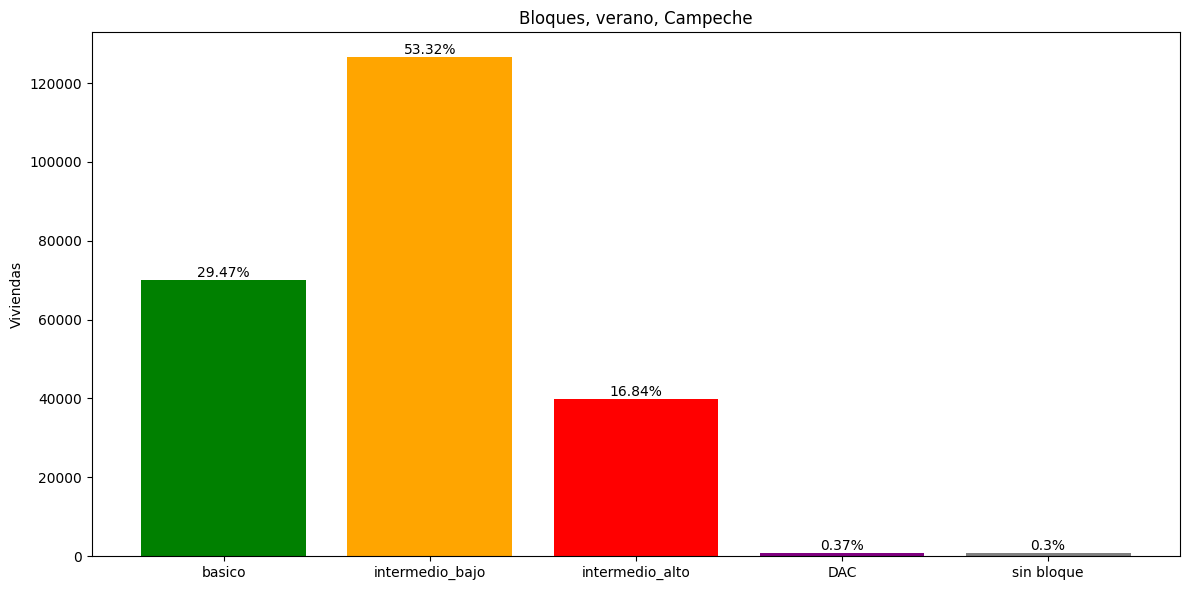

In [49]:
# Copia para graficar y asegurar que Viviendas sea numérica
tabla_plot = tabla.copy()
tabla_plot["Viviendas"] = tabla_plot["Viviendas"].replace({",": ""}, regex=True).astype(int)

colores = ['green','orange','red','purple','gray']
plt.figure(figsize=(12,6))
bars = plt.bar(tabla_plot["Bloque"], tabla_plot["Viviendas"], color=colores)

# plt.xticks(rotation=45)
plt.ylabel("Viviendas")
plt.title("Bloques, verano, Campeche")

# Agregar los porcentajes arriba de cada barra
for bar, pct in zip(bars, tabla_plot["Porcentaje (%)"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height,
        f"{pct}%", 
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()


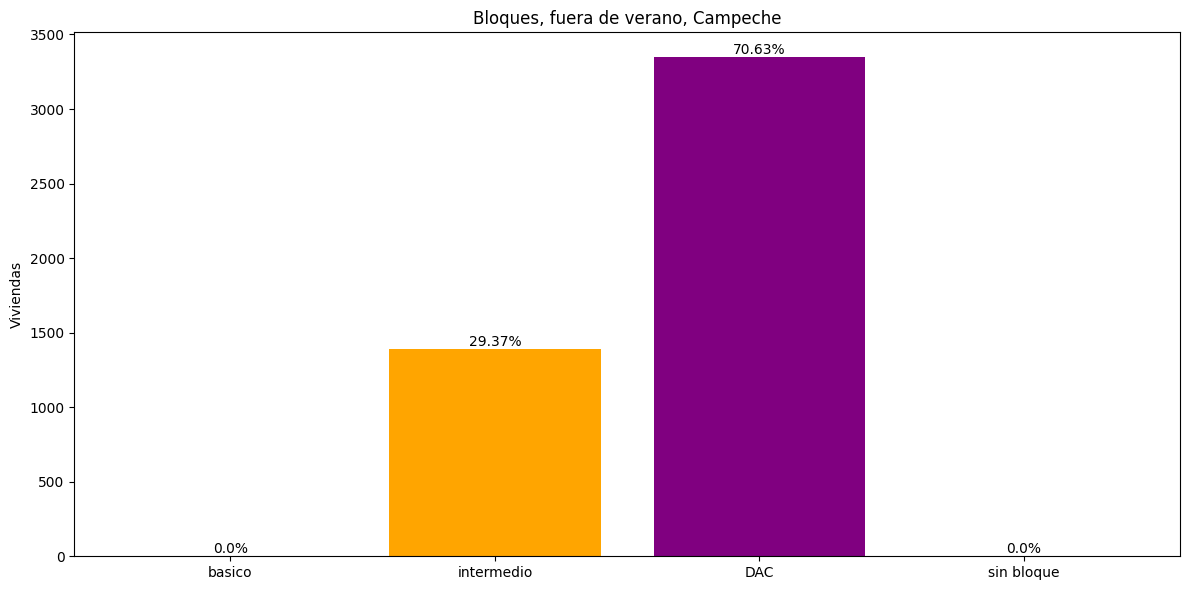

In [50]:
no_verano = ["enero","febrero","marzo", "octubre", "noviembre", "diciembre"]

df_verano = edo_df.loc[edo_df['mes_tarifa_nombre'].isin(no_verano)]

viv_verano = df_verano.loc[edo_df['bloque'].notna(), 'factor'].sum()
DACs_verano = df_verano.loc[df_verano['bloque'] == 'DAC', 'factor'].sum()
basico_verano = df_verano.loc[df_verano['bloque'] == 'basico', 'factor'].sum()
int_verano = df_verano.loc[df_verano['bloque'] == 'intermedio', 'factor'].sum()
bloque_nan_verano = df_verano.loc[df_verano['bloque'].isna(), 'factor'].sum()

# --- Crear tabla ---
tabla = pd.DataFrame({
    "Bloque": ["basico", "intermedio", 'DAC', "sin bloque"],

    "Viviendas": [
        basico_verano, int_verano, DACs_verano, bloque_nan_verano
    ]
})

# --- Porcentajes respecto al total calculable ---
tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_verano * 100).round(2)

# --- Formato con separador de miles ---
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")

# Copia para graficar y asegurar que Viviendas sea numérica
tabla_plot = tabla.copy()
tabla_plot["Viviendas"] = tabla_plot["Viviendas"].replace({",": ""}, regex=True).astype(int)

# Meses que deben eir en color naranja
# meses_naranja = ["abril", "mayo", "junio", "julio", "agosto", "septiembre"]

# # Asignar color a cada barra
colores = ['green','orange','purple','gray']

# Crear la gráfica
plt.figure(figsize=(12,6))
bars = plt.bar(tabla_plot["Bloque"], tabla_plot["Viviendas"]
               , color=colores
              )

# plt.xticks(rotation=45)
plt.ylabel("Viviendas")
plt.title("Bloques, fuera de verano, Campeche")

# Agregar los porcentajes arriba de cada barra
for bar, pct in zip(bars, tabla_plot["Porcentaje (%)"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height,
        f"{pct}%", 
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

## Suponiendo que el subsidio fue planeado de acuerdo a los meses más calidos dentro de la temporada de subsidio, esto solo para los meses que caen en temporada de verano 

In [51]:
df_UTCI = pd.read_csv('../data/modificado/subsidio_UTCI.csv')/
df_UTCI = df_UTCI.set_index("nombre_mes")
df_UTCI

SyntaxError: invalid syntax (3348268761.py, line 1)

Con la Tarifa Eléctrica 1F, la más baja del país, los campechanos tendrán un ahorro en los recibos de entre el 20% al 40%, además el Subsidio a la Energía Eléctrica se mantiene por tercer año consecutivo, con una inversión de $72 millones que aplicará del 1 de abril al 30 de septiembre de 2024. https://www.eleconomista.com.mx/politica/La-gobernadora-Layda-Sansores-San-Roman-firmo-el-convenio-para-la-reduccion-del-costo-de-la-energia-electrica-para-todo-el-estado-20231211-0085.html

In [ ]:
df_UTCI["subsidio"] = 72000000 * df_UTCI["subsidio_area_calida_percent"] / 100
df_UTCI

CN = CB * 1.22 - S

In [ ]:
# Los porcentajes fueron elegidos al tanteo
# Falta quitar los impuestos
# Seria bueno buscar en Hernadez como queda al final la reparticion de subsidio federal en cunato a caracteristicas economicas, 
# y de ahi ver como repartimos el subsidio estatal. O ver si el estado declara que criterios utilizan para repartir el subsidio, si dan 
# un monto para cada bloque o como 

edo_df["subsidio_men"] = 0.0

edo_df.loc[
    (edo_df["bloque"] == "basico"),
    "subsidio_men"
] = edo_df["gasto_men"] * 0.13

edo_df.loc[
    (edo_df["bloque"] == "intermedio_bajo"),
    "subsidio_men"
] = edo_df["gasto_men"] *0.08

edo_df.loc[
    (edo_df["bloque"] == "intermedio_alto"),
    "subsidio_men"
] = edo_df["gasto_men"] *0.05


In [ ]:
print(f'{round( (edo_df["factor"] * edo_df["subsidio_men"]).sum() ,2):,}')
print(f'{round(subsidio_ENIGH,2):,}')

In [ ]:
total = edo_df.loc[
edo_df["bloque"].isna() 
| (edo_df["bloque"] == "basico")
| (edo_df["bloque"] == "intermedio_bajo")
| (edo_df["bloque"] == "intermedio_alto")
| (edo_df["bloque"] == "DAC")
, "factor"].sum()

print(f'{round(total,2):,}')

In [ ]:
(edo_df["tot_resid"]*edo_df["factor"]).sum()

In [ ]:
edo_df["gasto_men_neto"] = (edo_df["gasto_men"] + edo_df["subsidio_men"])/1.22
edo_df

In [ ]:
def calcular_kWh_men(row):
    if pd.isna(row['bloque']):
        return np.nan
    elif row['bloque'] == 'DAC':
        return (row['gasto_men_neto'] - 130.52) / 5.337
    elif row['bloque'] == 'basico':
        return row['gasto_men_neto'] / 0.767
    elif row['bloque'] == 'intermedio_bajo':
        return (row['gasto_men_neto'] - 300*0.767) / 0.955 + 300
    elif row['bloque'] == 'intermedio_alto':
        return (row['gasto_men_neto'] - 300*0.767 - 900*0.955) / 2.322 + 300 + 900
    else:
        return np.nan  # Por si aparece un valor inesperado en 'bloque'

# Crear la nueva columna kWh_tri
edo_df['kWh_men'] = edo_df.apply(calcular_kWh_men, axis=1)
edo_df

In [ ]:
edo_df[["folioviv","gasto_men","bloque","subsidio_men","gasto_men_neto","kWh_men"]].to_csv("../data/modificado/luz_Campeche.csv", index=False)

In [ ]:
prueba = pd.read_csv("../data/modificado/luz_Campeche.csv")
prueba

In [ ]:
edo_df.dtypes

In [ ]:
viv_original = edo_df_original['factor'].sum()
viv_con_consumo = edo_df.loc[edo_df["kWh_men"].notna(), "factor"].sum()
viv_sin_consumo = viv_original - viv_con_consumo

print(f'''Se consiguieron: {round(viv_con_consumo,2):,} ({round(100*viv_con_consumo/viv_original,2):,}%) viviendas con consumo 
y {round(viv_sin_consumo,2):,} ({round(100*viv_sin_consumo/viv_original,2):,}%) viviendas sin consumo ''')


In [ ]:
viv_original = VIVIENDA_edo['factor'].sum()
viv_con_consumo = edo_df.loc[edo_df["bloque"].notna(), "factor"].sum()*0.711
viv_sin_consumo = viv_original - viv_con_consumo

print(f'''Se consiguieron: {round(viv_con_consumo,2):,} ({round(100*viv_con_consumo/viv_original,2):,}%) viviendas con consumo 
y {round(viv_sin_consumo,2):,} ({round(100*viv_sin_consumo/viv_original,2):,}%) viviendas sin consumo ''')


In [ ]:
edo_df_original

In [ ]:
viv_original

In [ ]:
viv_con_consumo

In [ ]:
edo_df.dtypes

In [ ]:
edo_df.loc[edo_df['disp_elect'] != 1, 'factor'].sum()

In [ ]:
min_men = 0.767 * 25* 1.22
edo_df.loc[edo_df['gasto_men'] < min_men, 'factor'].sum()

In [ ]:
edo_df[edo_df['gasto_men'] < min_men]